Dataset loaded with 50 rows.

--- Data Preview ---
   district     price  sq_meters  building_age earthquake_risk   price_per_m2
0  Besiktas  22000000        100            25          Medium  220000.000000
1  Besiktas  35000000        150            10          Medium  233333.333333
2  Bakirkoy  18000000        120            35            High  150000.000000
3  Bakirkoy  12000000         90            40            High  133333.333333
4   Kadikoy  14000000        110            22          Medium  127272.727273


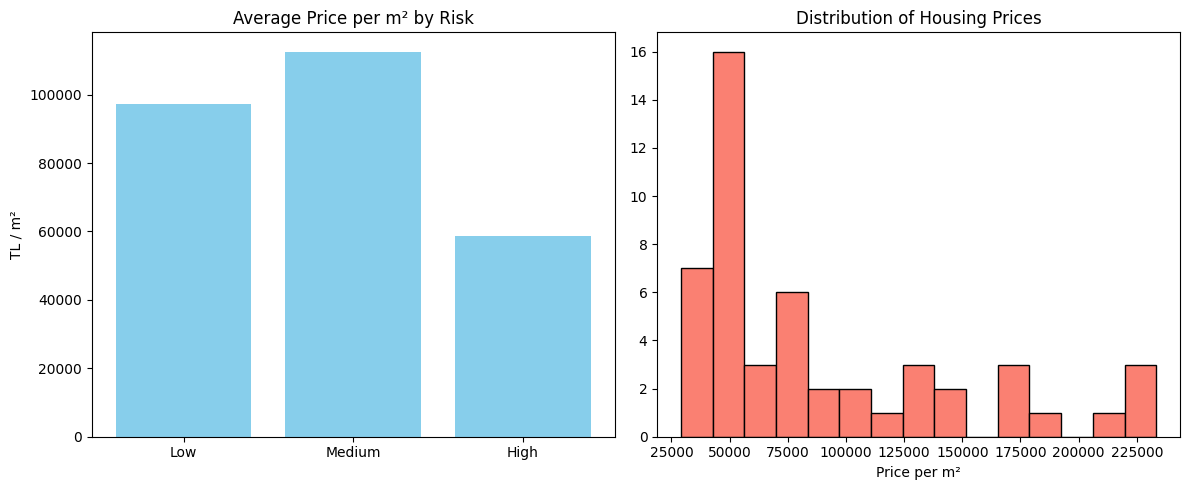


TEST 1: ANOVA (All 3 Groups)
H0: Prices are equal across all risks
ANOVA P-value: 0.0124295178

TEST 2: T-TEST (Low vs High Risk Only)
H0: No difference between Low and High risk zones
T-Test P-value: 0.0233287893

--- FINAL SUMMARY ---
Decision: Evidence suggests earthquake risk levels impact housing prices.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Loading Data
df = pd.read_csv("istanbul_housing.csv")
df['price_per_m2'] = df['price'] / df['sq_meters']

print(f"Dataset loaded with {df.shape[0]} rows.")
print("\n--- Data Preview ---")
print(df.head())

# 2. EDAs
# Graph 1: Bar Chart (Mean Price per Risk)
risk_levels = ["Low", "Medium", "High"]
avg_prices = [df[df["earthquake_risk"] == r]["price_per_m2"].mean() for r in risk_levels]

plt.figure(figsize=(12, 5))

# Subplot 1: Bar Chart
plt.subplot(1, 2, 1)
plt.bar(risk_levels, avg_prices, color="skyblue")
plt.title("Average Price per m² by Risk")
plt.ylabel("TL / m²")

# Subplot 2: Histogram (Price Distribution)
plt.subplot(1, 2, 2)
plt.hist(df['price_per_m2'], bins=15, color="salmon", edgecolor='black')
plt.title("Distribution of Housing Prices")
plt.xlabel("Price per m²")

plt.tight_layout()
plt.show()

# 3. HYPOTHESIS TESTING
print("\n" + "="*30)
print("TEST 1: ANOVA (All 3 Groups)")
low_risk = df[df["earthquake_risk"] == "Low"]["price_per_m2"]
med_risk = df[df["earthquake_risk"] == "Medium"]["price_per_m2"]
high_risk = df[df["earthquake_risk"] == "High"]["price_per_m2"]

f_stat, p_anova = stats.f_oneway(low_risk, med_risk, high_risk)
print(f"H0: Prices are equal across all risks")
print(f"ANOVA P-value: {p_anova:.10f}")

print("\n" + "="*30)
print("TEST 2: T-TEST (Low vs High Risk Only)")
t_stat, p_ttest = stats.ttest_ind(low_risk, high_risk)
print(f"H0: No difference between Low and High risk zones")
print(f"T-Test P-value: {p_ttest:.10f}")

print("\n--- FINAL SUMMARY ---")
if p_anova < 0.05:
    print("Decision: Evidence suggests earthquake risk levels impact housing prices.")
else:
    print("Decision: No significant statistical impact found.")

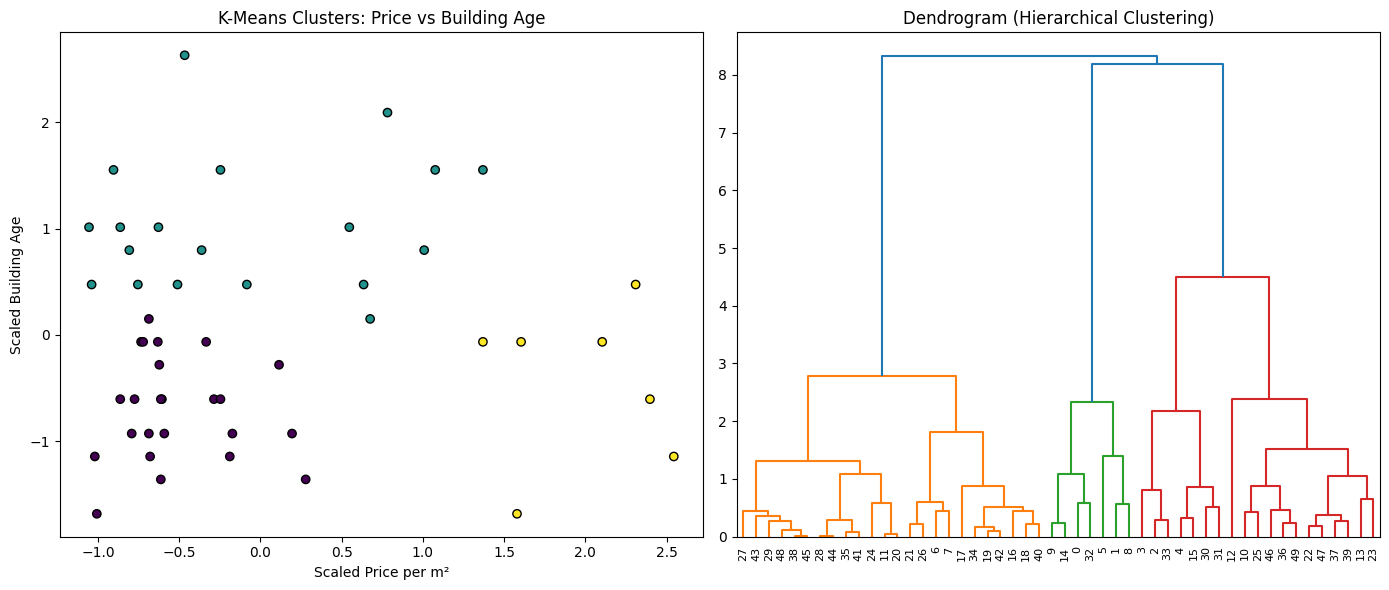


--- Cluster Analysis by Earthquake Risk ---
cluster_label  earthquake_risk
0              Low                10
               Medium              8
               High                6
1              High               12
               Medium              6
               Low                 1
2              Medium              4
               Low                 3
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch

X = df[['price_per_m2', 'building_age']]

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# k-means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster_label'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(14, 6))

# scatter plot
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['cluster_label'], cmap='viridis', edgecolors='black')
plt.title("K-Means Clusters: Price vs Building Age")
plt.xlabel("Scaled Price per m²")
plt.ylabel("Scaled Building Age")

# dendrogram
plt.subplot(1, 2, 2)
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram (Hierarchical Clustering)")

plt.tight_layout()
plt.show()

# validation
print("\n--- Cluster Analysis by Earthquake Risk ---")
print(df.groupby('cluster_label')['earthquake_risk'].value_counts())